In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np

In [3]:

df = pd.read_csv(r"C:\Users\Dipak\Downloads\creditcard (1).csv")
df


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39697,39927,-1.466679,2.425732,0.877724,3.950765,0.762477,1.162748,0.575625,-0.288354,-1.357990,...,0.186051,0.571010,-0.107517,-0.754306,-0.752828,0.113179,-2.079421,-0.809173,1.50,0.0
39698,39927,-0.523165,-0.100021,0.892966,-1.900405,-0.156870,-0.783894,0.917683,-0.308345,-1.305284,...,-0.082504,-0.414677,-0.063392,-0.087455,-0.303383,-0.682889,-0.178417,-0.137169,100.92,0.0
39699,39928,-2.768425,-1.007072,2.151127,0.117797,1.283178,1.869731,-0.562240,0.820374,0.348797,...,-0.182963,0.778210,0.904077,-1.288631,0.212441,0.483975,-0.027614,-0.582813,11.99,0.0
39700,39928,1.201327,0.158614,-0.325263,0.471667,0.086446,-0.770357,0.422151,-0.205277,-0.451865,...,0.027664,-0.018485,-0.199382,0.053605,0.683829,0.428416,-0.077342,-0.006394,45.00,0.0


In [4]:
df = df.drop(['Time','Class'], axis = 1)
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39697,-1.466679,2.425732,0.877724,3.950765,0.762477,1.162748,0.575625,-0.288354,-1.357990,2.907686,...,0.129962,0.186051,0.571010,-0.107517,-0.754306,-0.752828,0.113179,-2.079421,-0.809173,1.50
39698,-0.523165,-0.100021,0.892966,-1.900405,-0.156870,-0.783894,0.917683,-0.308345,-1.305284,0.514227,...,-0.071640,-0.082504,-0.414677,-0.063392,-0.087455,-0.303383,-0.682889,-0.178417,-0.137169,100.92
39699,-2.768425,-1.007072,2.151127,0.117797,1.283178,1.869731,-0.562240,0.820374,0.348797,-0.122472,...,-0.491556,-0.182963,0.778210,0.904077,-1.288631,0.212441,0.483975,-0.027614,-0.582813,11.99
39700,1.201327,0.158614,-0.325263,0.471667,0.086446,-0.770357,0.422151,-0.205277,-0.451865,0.161808,...,-0.023074,0.027664,-0.018485,-0.199382,0.053605,0.683829,0.428416,-0.077342,-0.006394,45.00


In [5]:
#preprocessing the data 
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split 
x_train , x_test = train_test_split(df, test_size = 0.2)

In [6]:
print(x_train.shape[1])
print(x_test.shape[1])
type(x_train)

29
29


pandas.core.frame.DataFrame

In [7]:
from keras.models import Model , Sequential 
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import layers, models 

In [8]:
#The only requirement is the dimensionality of the input and output needs to be the same Anything in the middle can be played with..
encoder = tf.keras.models.Sequential([
    layers.Input(shape=(x_train.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(20, activation='relu')
])
        
decoder = tf.keras.models.Sequential([
    layers.Input(shape=(20,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(x_train.shape[1], activation='linear')  # Use linear activation for reconstruction
])
        
model = tf.keras.models.Sequential([
    encoder,
    decoder
])

In [9]:

model.compile(optimizer='adam', loss ='mean_squared_error')


In [10]:
history = model.fit(
    x_train, 
    x_train, 
    validation_data=(x_test,x_test),
    epochs=5,
    batch_size = 100,
    shuffle=True
)

Epoch 1/5
318/318 ━━━━━━━━━━━━━━━━━━━━ 19s 19ms/step - loss: nan - val_loss: nan
Epoch 2/5
318/318 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: nan - val_loss: nan
Epoch 3/5
318/318 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: nan - val_loss: nan
Epoch 4/5
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: nan - val_loss: nan
Epoch 5/5
318/318 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: nan - val_loss: nan


<Axes: >

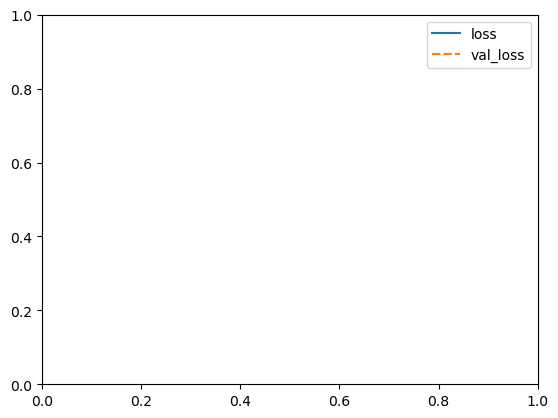

In [11]:

import seaborn as sns
sns.lineplot(model.history.history)

In [12]:
predictions = model.predict(x_test)
mse = np.mean(np.power(x_test - predictions, 2), axis=1)

249/249 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step 


In [13]:
threshold = np.percentile(mse, 95)  # Adjust the percentile as needed
threshold

np.float64(3.3649394054104746)

In [14]:

anomalies = mse > threshold

In [15]:
# Calculate the number of anomalies
num_anomalies = np.sum(anomalies)
print(f"Number of Anomalies: {num_anomalies}")

Number of Anomalies: 397


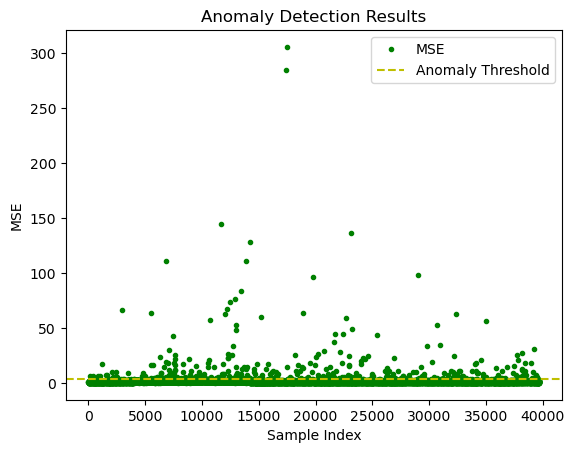

In [16]:

#Plot the anomalies
import matplotlib.pyplot as plt
# plt.figure(figsize=(12, 6))
plt.plot(mse, color='g',marker='o', linestyle='', markersize=3, label='MSE', )
plt.axhline(threshold, color='y', linestyle='--', label='Anomaly Threshold')
plt.xlabel('Sample Index')
plt.ylabel('MSE')
plt.title('Anomaly Detection Results')
plt.legend()
plt.show()